In [1]:
import sys
import os

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
file_path = "../data/Expenditure-of-local-bodies.xlsx"
if not os.path.exists(file_path):
    print("Dataset not found!")
else:
    print("Good to go!")

Good to go!


In [3]:
from feature_engineering import FeatureExtraction, FeatureExtractionTotal
from visualization import CompositionAnalysis, PerformanceAnalysis, PieCharts
import pandas as pd

In [4]:
feature_extraction = FeatureExtraction(fname=file_path, province_name="Province 1")
all_content_df = feature_extraction.open_file().copy()
all_content_df_renamed = feature_extraction.rename_label(dataframe=all_content_df).copy()
budget_df = feature_extraction.extract_budget_frame(dataframe=all_content_df_renamed).copy()
expense_df = feature_extraction.extract_expenditure_frame(dataframe=all_content_df_renamed).copy()


In [5]:
budget_df.head(8)

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,38.550184,26.144191,0.0,64.694376,7.666711
1,2,Aathrai Tribeni Rural Municipality,26.79269,22.705015,0.0,49.497705,12.857007
2,3,Phaktanglung Rural Municipality,30.862931,15.232376,0.0,46.095307,7.17987
3,4,Mikwakhola Rural Municipality,20.730677,11.014579,0.0,31.745256,6.718961
4,5,Meringdeng Rural Municipality,26.518959,16.155819,0.0,42.674779,2.881517
5,6,Mauwakhola Rural Municipality,21.46895,14.5531,0.0,36.02205,4.327077
6,7,Pathibhara Yangwarak Rural Municipality,27.369047,21.029567,0.0,48.398614,6.686506
7,8,Sidingwa Rural Municipality,30.86315,12.018302,0.0,42.881452,5.39351


In [6]:
feature_extraction_total = FeatureExtractionTotal(budget_frame=budget_df, exp_frame=expense_df)
budget_df_total, expense_df_total = feature_extraction_total.extract_total()
budget_df_total.head(8)

Index extracted 😍
Frame for total extracted 😍
Successful 😍


,Province,Recurrent,Capital,Financial,Total,Cash Balance
137,Province 1 Total,5081.831834,3874.215984,10.0477,8966.095518,1387.038128
275,Madesh Province Total,4734.203008,4193.549548,1.4616,8929.214156,1622.605338
396,Bagmati Province Total,5738.416834,6653.583849,44.8226,12436.823283,3564.238124
483,Gandaki Province Total,3214.196403,2287.84544,2.71,5504.751844,1019.491616
594,Lumbini Province Total,4493.042024,3640.922365,5.278074,8139.242463,1514.624353
675,Karnali Province Total,2493.164023,1696.912999,0.5819,4190.658922,504.506444
765,Sudurpaschim Province Total,3062.187398,2068.968939,0.4231,5131.579438,544.253354


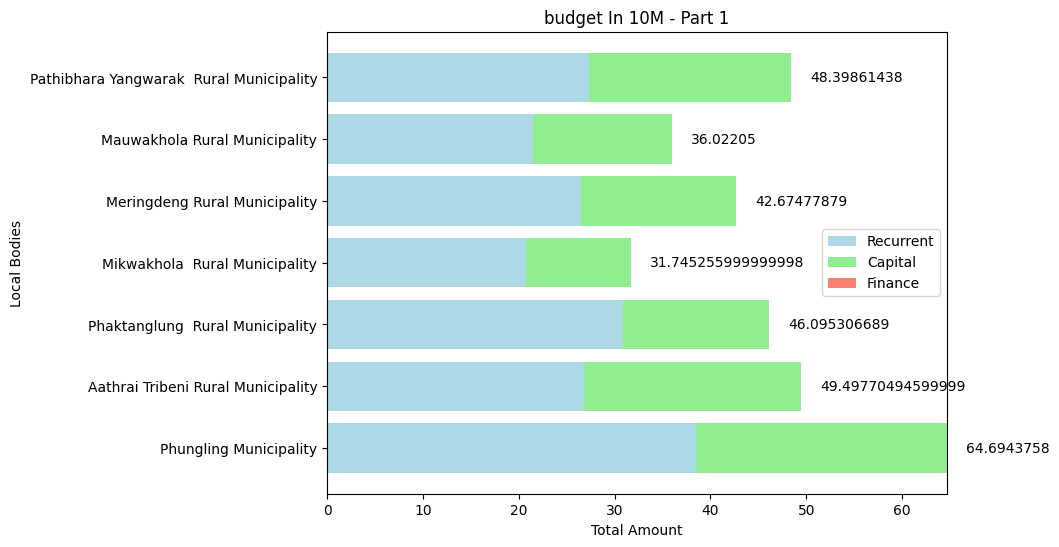

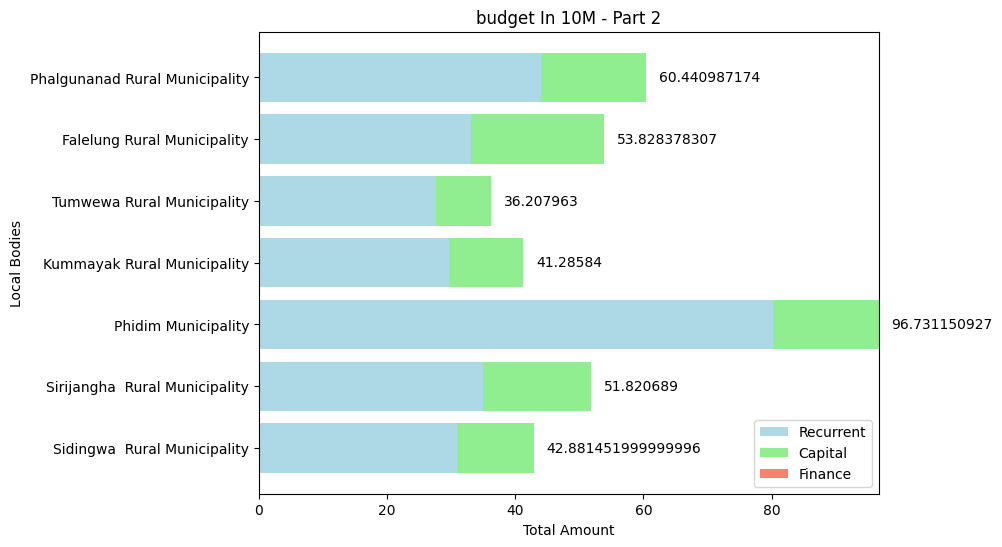

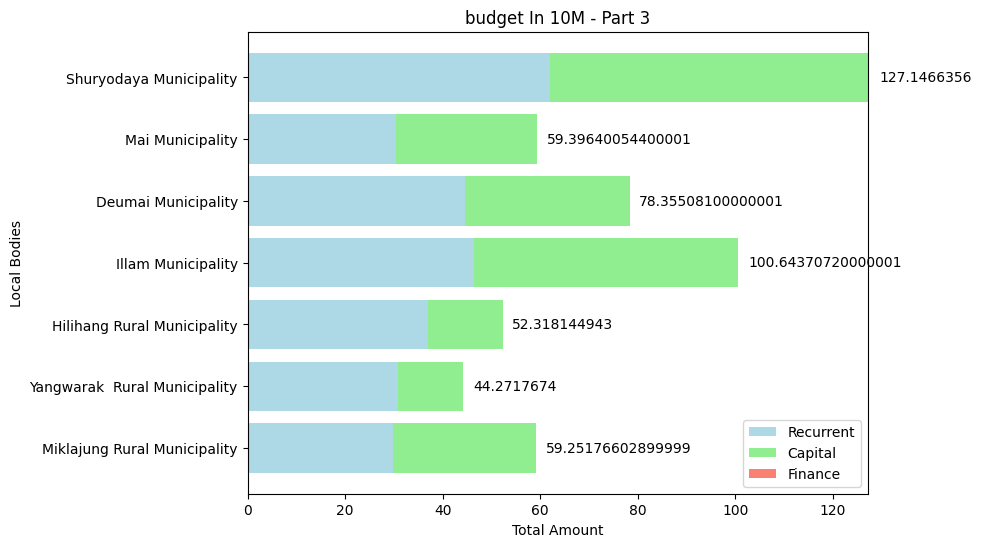

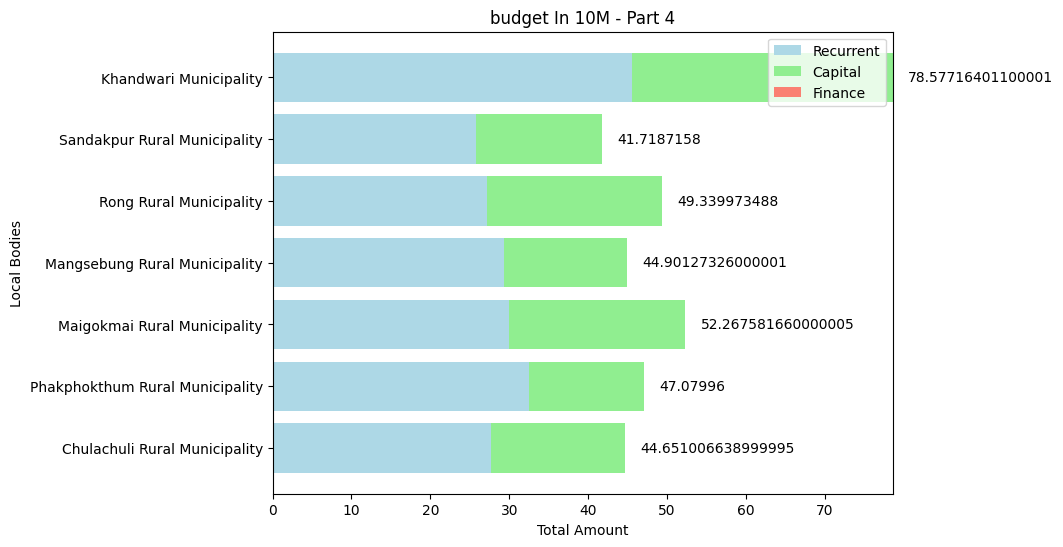

In [7]:
composition_analysis = CompositionAnalysis(dataframe=budget_df, title="budget", total_attributes_limit=28)
# total_attributes_limit can be adjusted 
composition_analysis.plot_composition_bar()

In [8]:
color_dict = {
            'Recurrent': '#d42a08',
            'Capital': '#08d427',
            'Financial': '#a808d4'
        }

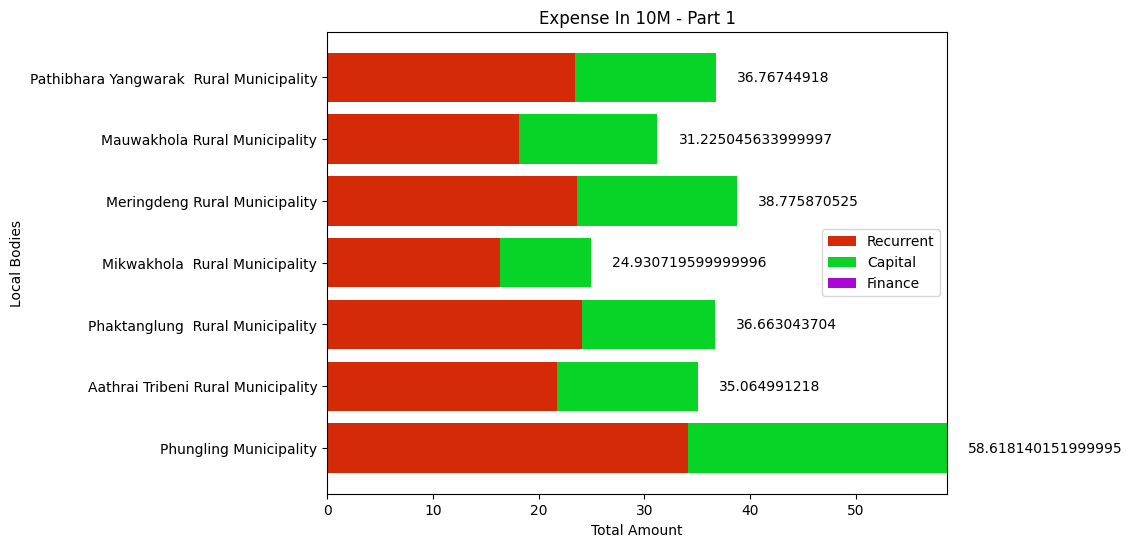

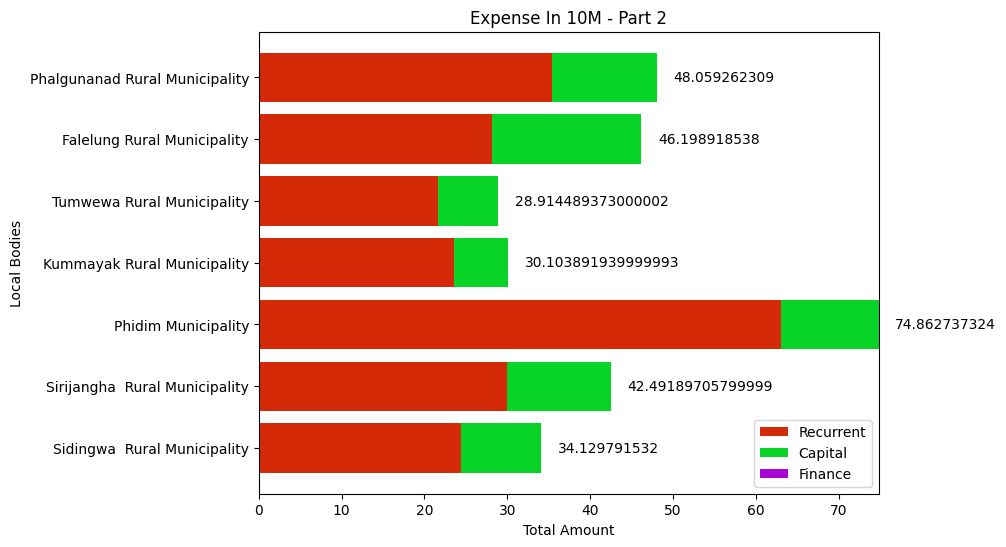

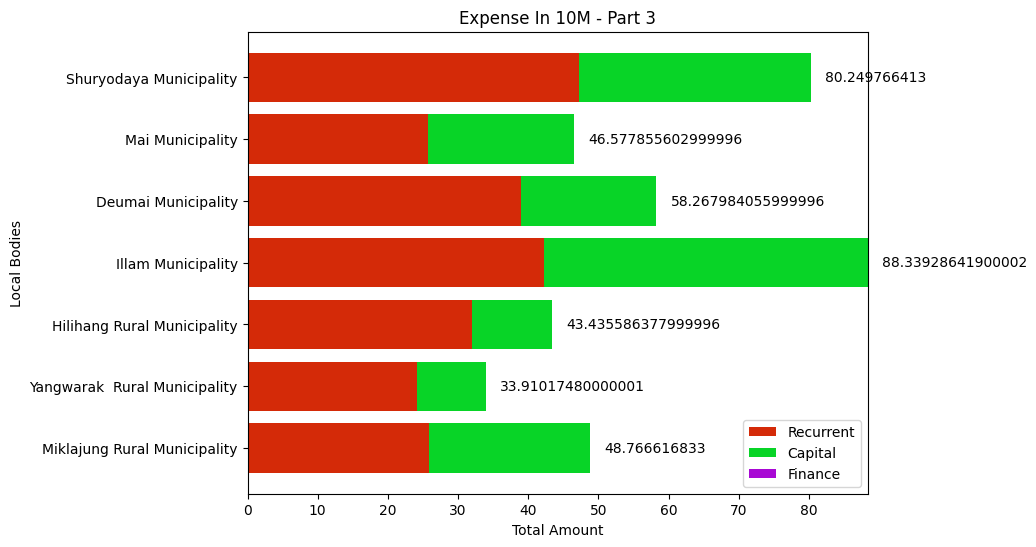

In [9]:
composition_analysis = CompositionAnalysis(dataframe=expense_df, title="Expense", total_attributes_limit=21, bar_colors=color_dict)
composition_analysis.plot_composition_bar()

In [10]:
feature_extraction = FeatureExtraction(fname=file_path, province_name="Province 1")
budget_df, expense_df = feature_extraction.extract_individual()

Original data extracted successfully☺️
DataFrame Renamed successfully☺️
ALL THE OPERSTIONS WERE SUCCESSFUL😊


In [11]:
budget_df.head()

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,38.550184,26.144191,0.0,64.694376,7.666711
1,2,Aathrai Tribeni Rural Municipality,26.79269,22.705015,0.0,49.497705,12.857007
2,3,Phaktanglung Rural Municipality,30.862931,15.232376,0.0,46.095307,7.17987
3,4,Mikwakhola Rural Municipality,20.730677,11.014579,0.0,31.745256,6.718961
4,5,Meringdeng Rural Municipality,26.518959,16.155819,0.0,42.674779,2.881517


/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:46: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  self.dataframe_expense['Utilization_Rate'] = self.dataframe_expense['Utilization_Rate'].fillna(0)
/home/khagendra/Projects/python/BudgetAndExpenditureofLocalBodiesinFY2021-22/visualization/performance.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


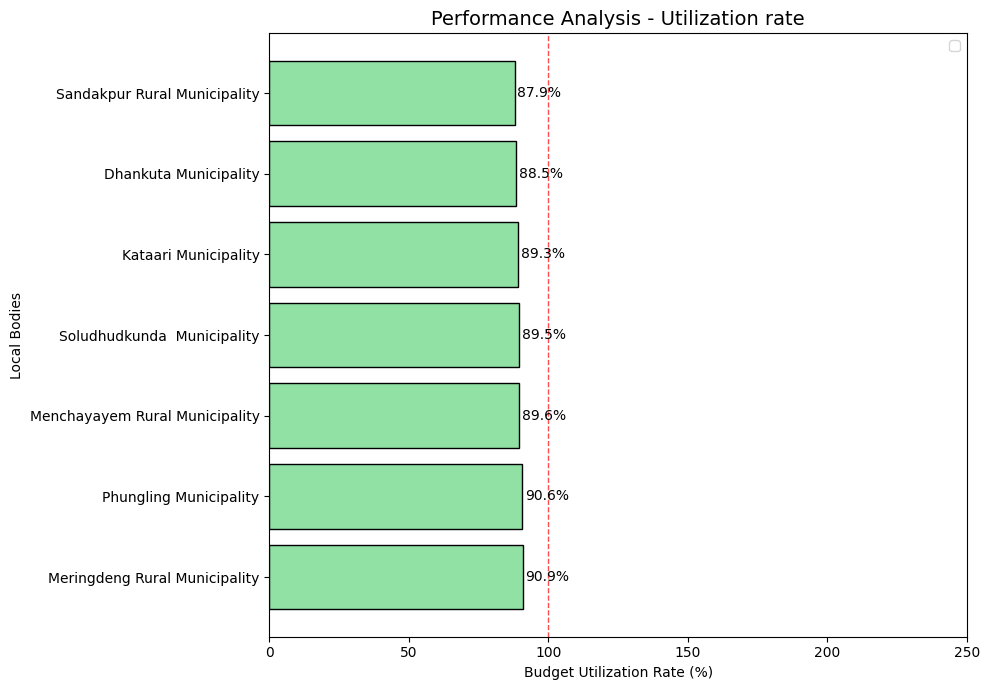

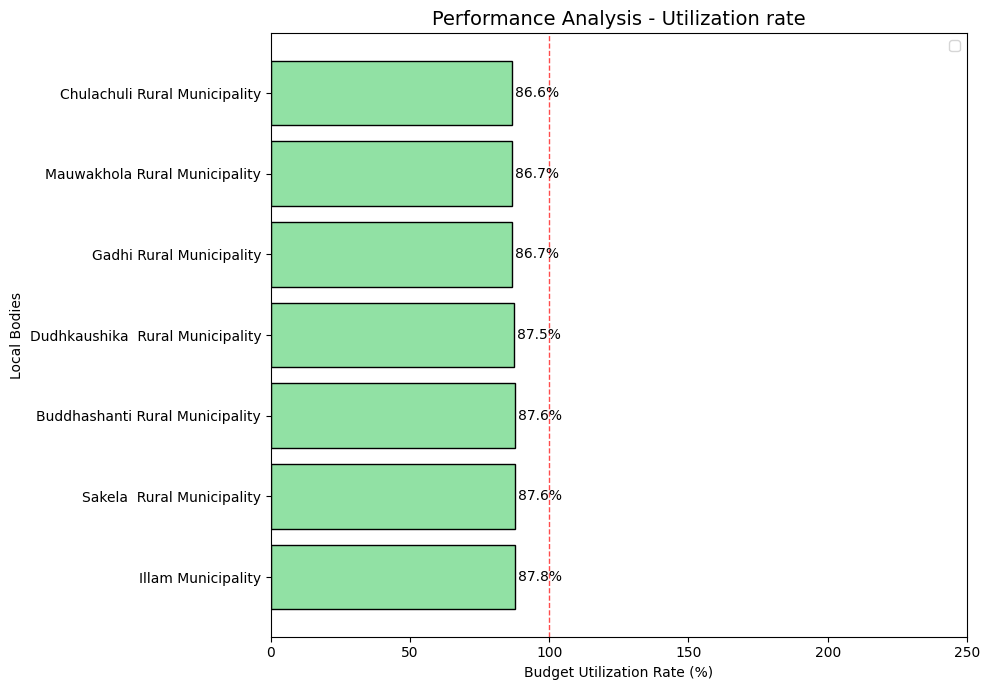

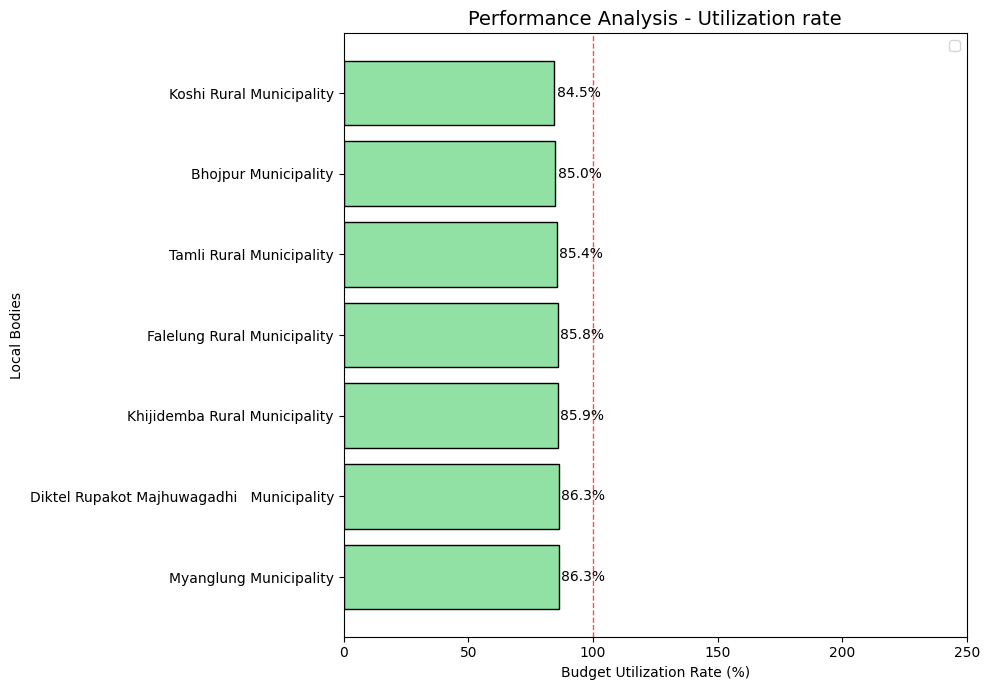

In [12]:
performance_analysis = PerformanceAnalysis(dataframe_budget=budget_df,
                                           dataframe_expense=expense_df)
performance_analysis.plot_utilization_bar()

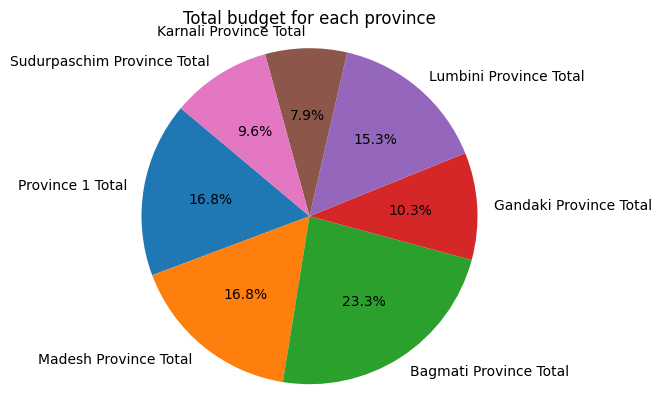

In [13]:
pie_charts = PieCharts(expense_frame=expense_df,
                       budget_frame=budget_df,
                       expense_total=expense_df_total,
                       budget_total=budget_df_total)
pie_charts.plot_for_total()

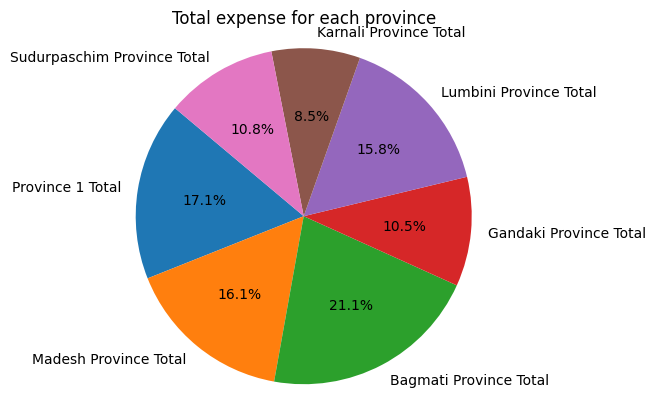

In [14]:
# For expense 
pie_charts.plot_for_total(type='expense')

In [15]:
expense_df.sort_values(by="Total", ascending=False)
expense_df.head()

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
0,1,Phungling Municipality,34.104109,24.514032,0.0,58.61814,7.666711
1,2,Aathrai Tribeni Rural Municipality,21.72991,13.335082,0.0,35.064991,12.857007
2,3,Phaktanglung Rural Municipality,24.071506,12.591538,0.0,36.663044,7.17987
3,4,Mikwakhola Rural Municipality,16.349711,8.581009,0.0,24.93072,6.718961
4,5,Meringdeng Rural Municipality,23.587589,15.188281,0.0,38.775871,2.881517


In [16]:
expense_df.tail()

,SN,Local Body,Recurrent,Capital,Financial,Total,Cash Balance
133,134,Dewangunj Rural Municipality,20.525654,20.33353,0.0,40.859184,17.222297
134,135,Barju Rural Municipality,27.443078,8.139141,0.0,35.58222,11.359134
135,136,Bhokraha Rural Municipality,23.000567,17.954467,0.0,40.955034,2.647668
136,137,Harinagar Rural Municipality,22.02033,20.121998,0.0,42.142328,12.253008
137,Province 1 Total,,4128.543863,2574.43002,7.968455,6710.942339,1387.038128


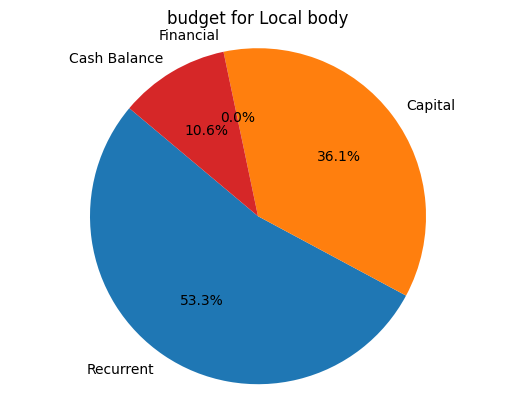

In [17]:
local_body_with_max_total = "Phungling Municipality"
local_body_with_min_total = "Dewangunj Rural Municipality"
pie_charts.plot_for_local_body(local_body=local_body_with_max_total) # default type is budget

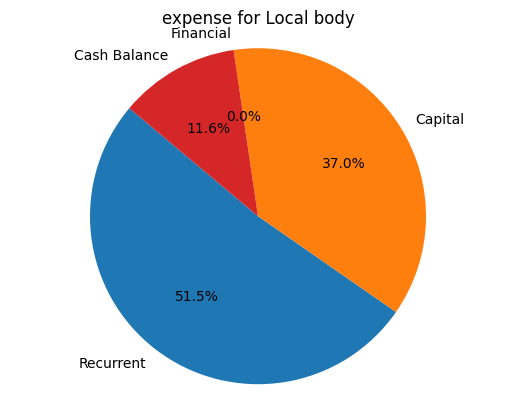

In [18]:
pie_charts.plot_for_local_body(local_body=local_body_with_max_total, type='expense')

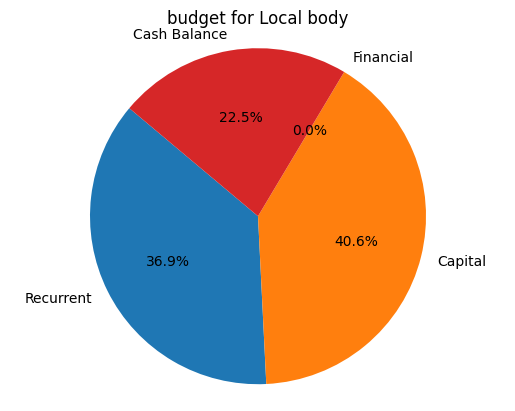

In [19]:
# Let's do the same for local body with min total
pie_charts.plot_for_local_body(local_body=local_body_with_min_total)

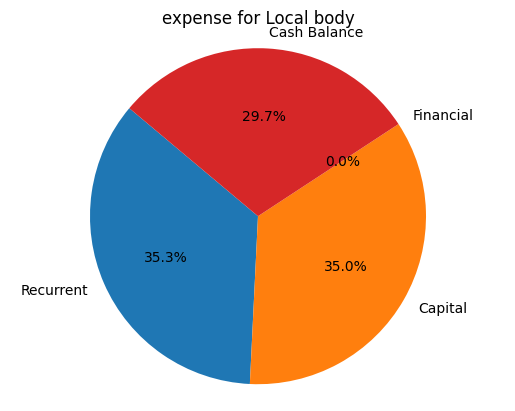

In [20]:
pie_charts.plot_for_local_body(local_body=local_body_with_min_total, type='expense')